In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
data=pd.read_csv("House/train.csv")

In [100]:
data.shape

(1460, 81)

df=data.copy()

(2, 81)
             SalePrice  TotalBsmtSF
SalePrice     1.000000     0.613581
TotalBsmtSF   0.613581     1.000000


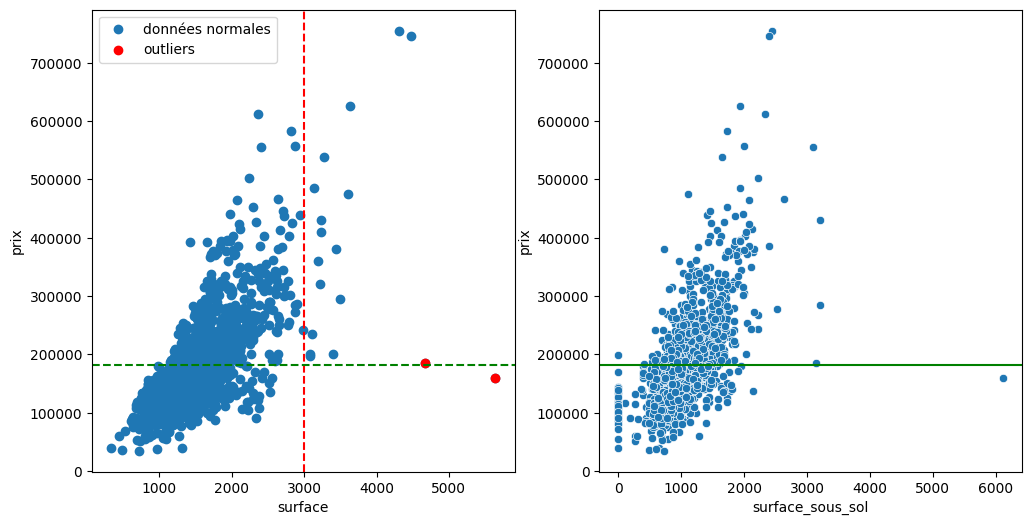

In [101]:
outliers_GA=data[(data['GrLivArea']>4000)  & (data['SalePrice']<300000)]
print(outliers_GA.shape)
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.scatter(data=data, x='GrLivArea', y='SalePrice', label='données normales')
plt.scatter(outliers_GA['GrLivArea'],outliers_GA['SalePrice'],color='red', label='outliers')
plt.axvline(x=3000, color='red', linestyle='--')
plt.axhline(y=data['SalePrice'].mean(), color='green', linestyle='--')
plt.xlabel("surface"); plt.ylabel("prix")
plt.legend()

plt.subplot(1,2,2)

sns.scatterplot(data=data, x='TotalBsmtSF', y='SalePrice')
plt.axhline(y=data['SalePrice'].mean(), color='green', linestyle='-')
plt.xlabel("surface_sous_sol"); plt.ylabel("prix")

print(data[['SalePrice','TotalBsmtSF']].corr())

In [102]:
#Analyse GrLivArea Vs SalePrice:
# Relation générale:
  # On observe une correlation positive ; plus la maison est grande plus le prix est elevé (relation linéaire logique : les grandes maisons valent plus chers);
  # On observe egalement que deux maisons peuvent avoir la meme surface mais pas le meme prix, il y'a donc d'autres variables qui influent sur le prix de la maison (la relation lineaire n'est donc pas pas parfaitement claire)
  # ON observe aussi quelques outliers : des maisons tres grandes à des prix tres bas (ici on va supprimer les utliers pour ne pas brouiller la regression et faire croire au modele qu'une grande surface n'implique pas un prix eélevé)
  # En outre on obtient 0.708624 de correlation ce qui implique une correlation tres forte entre les deux variables :Donc la surface sera une variable tres importante pour le modele

In [103]:
data.drop(outliers_GA.index,inplace=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'CollgCr'),
  Text(1, 0, 'Veenker'),
  Text(2, 0, 'Crawfor'),
  Text(3, 0, 'NoRidge'),
  Text(4, 0, 'Mitchel'),
  Text(5, 0, 'Somerst'),
  Text(6, 0, 'NWAmes'),
  Text(7, 0, 'OldTown'),
  Text(8, 0, 'BrkSide'),
  Text(9, 0, 'Sawyer'),
  Text(10, 0, 'NridgHt'),
  Text(11, 0, 'NAmes'),
  Text(12, 0, 'SawyerW'),
  Text(13, 0, 'IDOTRR'),
  Text(14, 0, 'MeadowV'),
  Text(15, 0, 'Edwards'),
  Text(16, 0, 'Timber'),
  Text(17, 0, 'Gilbert'),
  Text(18, 0, 'StoneBr'),
  Text(19, 0, 'ClearCr'),
  Text(20, 0, 'NPkVill'),
  Text(21, 0, 'Blmngtn'),
  Text(22, 0, 'BrDale'),
  Text(23, 0, 'SWISU'),
  Text(24, 0, 'Blueste')])

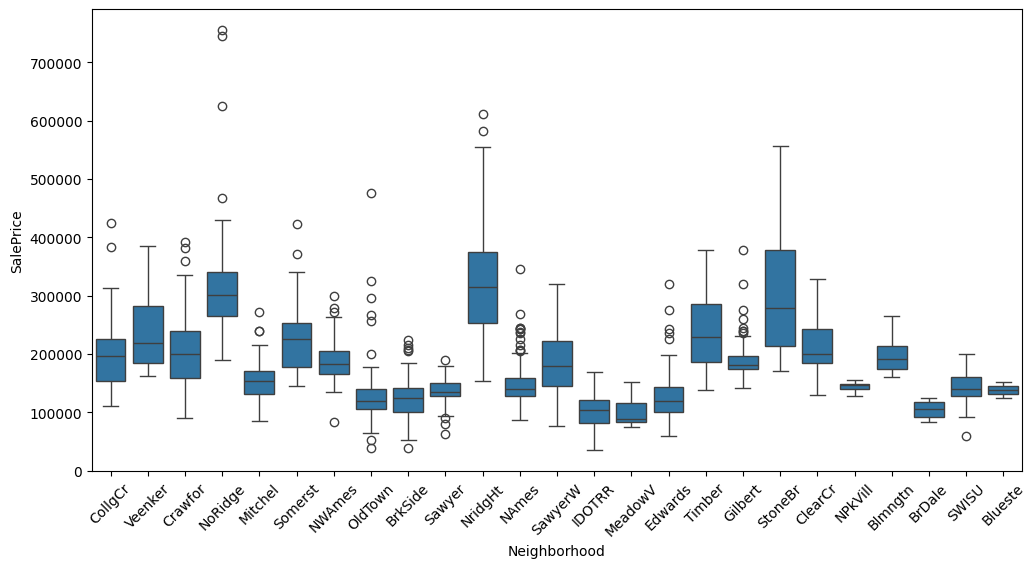

In [104]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=45)

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

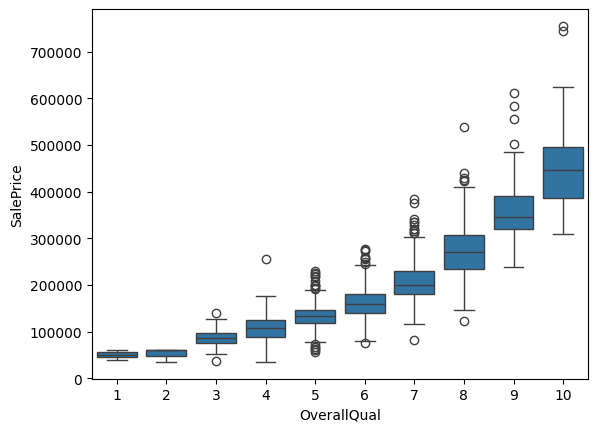

In [105]:
sns.boxplot(data=data, x='OverallQual', y='SalePrice')

In [106]:
# Catégorielles : NaN = absence logique
cols_fill_none =(data[data.columns[(data.isna().sum()>0) & (data.dtypes=='object')]].drop('Electrical', axis=1).columns).tolist()

data[cols_fill_none] = data[cols_fill_none].fillna('havn')

# Catégorielle : NaN = vraie donnée manquante
data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])

#Pour les variables numeriques
for col in data.select_dtypes(include='number'):
    data[col] = data[col].fillna(data[col].median())

In [107]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [110]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [116]:
x=data.drop('SalePrice', axis=1); y=data['SalePrice']
x_train, x_test, y_train, y_test=train_test_split(x,y, train_size=0.8,random_state=0)

In [117]:
categorical=x_train.select_dtypes(exclude='number').columns
numerical=x_train.select_dtypes(include='number').columns

In [118]:
processor=make_column_transformer((OneHotEncoder(handle_unknown='ignore'), categorical), (StandardScaler(),numerical))

In [119]:
model=make_pipeline(processor, LinearRegression())

In [120]:
model.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
models = {
    'linear':LinearRegression(),
     'rdf':  RandomForestRegressor(),
     'GB': GradientBoostingRegressor()
}
for name , mod in models.items():
    pip=make_pipeline(processor, mod)
    pip.fit(x_train,y_train)
    print(pip.score(x_train, y_train))

0.9451968888576968
0.9825698139082294
